In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import plotly.express as px
import matplotlib.pyplot as plt

neighborhood = pd.read_csv('../data/processed/neighborhood_activity.csv')
print(neighborhood.shape)
print(neighborhood.columns.tolist())

(596, 14)
['city', 'neighbourhood_cleansed', 'total_listings', 'avg_occupancy', 'median_price', 'commercial_pct', 'licensed_pct', 'avg_availability', 'avg_reviews', 'occupancy_rate', 'total_listings_norm', 'avg_occupancy_norm', 'commercial_pct_norm', 'activity_score']


In [2]:
# Features and target
features = [
    'avg_occupancy', 'median_price', 'commercial_pct', 
    'licensed_pct', 'avg_availability', 'avg_reviews',
    'occupancy_rate', 'city'
]

target = 'activity_score'

# Encode city as categorical
df = neighborhood[features + [target]].copy()
df['city'] = df['city'].astype('category')

# Drop rows with missing values
print(f"Before dropna: {len(df)}")
df = df.dropna()
print(f"After dropna: {len(df)}")

# Train/test split
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")
print(f"Target range: {y.min():.3f} — {y.max():.3f}")

Before dropna: 596
After dropna: 596

Train: 476 | Test: 120
Target range: 0.013 — 0.894


In [3]:
# Train LightGBM model
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=10,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² score: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"Best iteration: {model.best_iteration_}")

R² score: 0.684
MAE: 0.049
Best iteration: 49


In [4]:
# Tuned model
model_tuned = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

model_tuned.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_pred_tuned = model_tuned.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print(f"Tuned R² score: {r2_tuned:.3f}")
print(f"Tuned MAE: {mae_tuned:.3f}")
print(f"Best iteration: {model_tuned.best_iteration_}")

Tuned R² score: 0.708
Tuned MAE: 0.047
Best iteration: 138


## Model: LightGBM Activity Score Predictor

**Model:** LightGBM Regressor with early stopping  
**Train/Test split:** 80/20 (476 train, 120 test)  
**R² score:** 0.708 — model explains ~71% of variance in neighborhood activity scores  
**MAE:** 0.047 — average prediction error of 0.047 on a 0–1 scale  

The model performs reasonably well given the small dataset (596 neighborhoods).
R² of 0.708 suggests neighborhood characteristics capture most of the signal,
though local factors not in our data (proximity to attractions, zoning) 
likely explain the remaining variance.

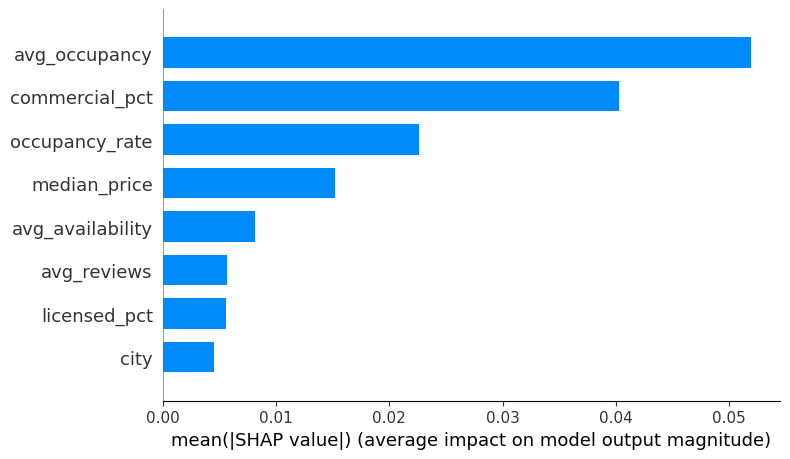

<Figure size 640x480 with 0 Axes>

In [5]:
# SHAP values
explainer = shap.TreeExplainer(model_tuned)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type='bar',
    title='Feature Importance (SHAP values)'
)
plt.tight_layout()
plt.show()

## SHAP Feature Importance

- **avg_occupancy** is the dominant predictor — how busy listings are 
  matters more than any other factor
- **commercial_pct** is second — neighborhoods with more professional/commercial 
  hosts consistently show higher activity
- **city** ranks last — neighborhood characteristics are more predictive 
  than which city a neighborhood is in

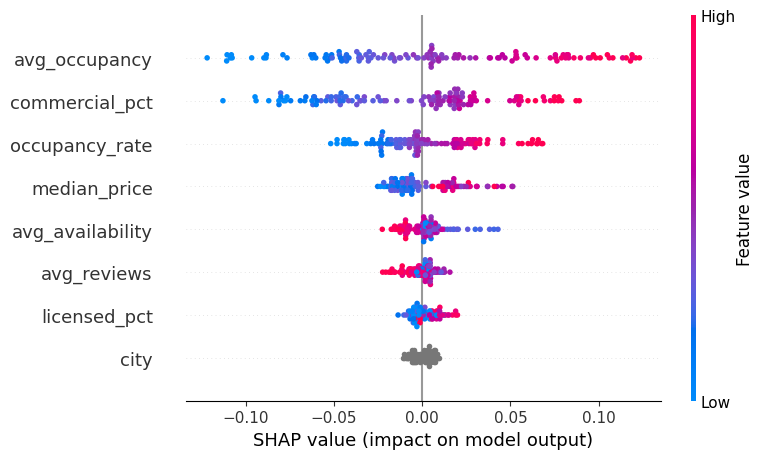

<Figure size 640x480 with 0 Axes>

In [6]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    title='SHAP Feature Impact'
)
plt.tight_layout()
plt.show()

## SHAP Beeswarm — Direction of Impact

- High occupancy (red) strongly pushes activity score up
- High commercial % (red) pushes activity up — property managers drive activity
- High availability (red) pushes activity DOWN — always-available listings 
  are less active, not more (likely inactive/poorly managed listings)
- Licensed % shows mixed signal — licensing alone doesn't determine activity level

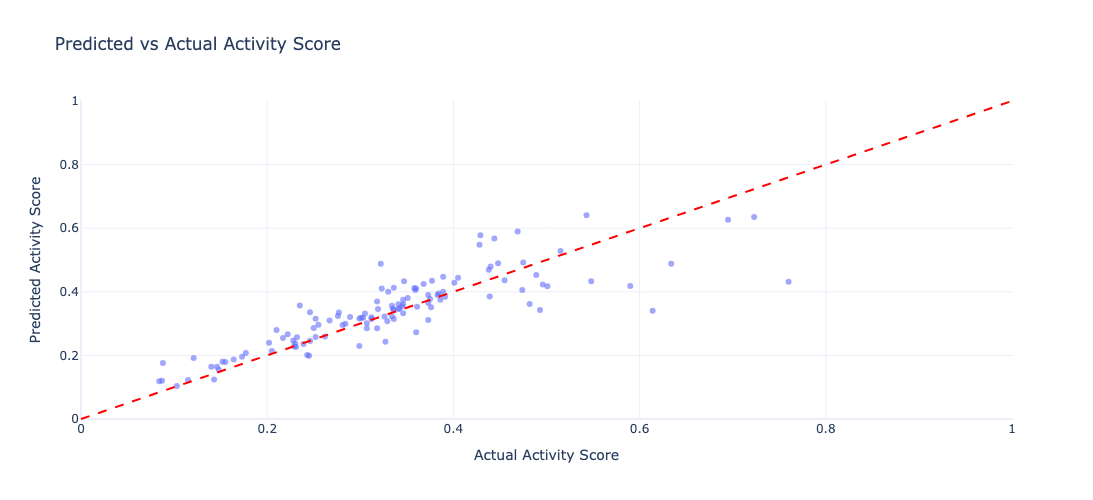

In [7]:
fig = px.scatter(
    x=y_test,
    y=y_pred_tuned,
    labels={'x': 'Actual Activity Score', 'y': 'Predicted Activity Score'},
    title='Predicted vs Actual Activity Score',
    template='plotly_white',
    opacity=0.6
)

fig.add_shape(
    type='line', x0=0, y0=0, x1=1, y1=1,
    line=dict(dash='dash', color='red')
)

fig.update_layout(height=500)
fig.show()

## Predicted vs Actual

Model performs well for low-to-mid activity scores but underpredicts 
high-activity neighborhoods (actual > 0.6). This is expected behavior 
for tree models on small datasets — extreme values are harder to predict 
without more training examples. A larger multi-city dataset or additional 
features (tourism proximity, transit access) would likely improve performance.

In [8]:
# Save SHAP values
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df.to_csv('../data/processed/shap_values.csv', index=False)

# Save test predictions
pred_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_tuned
})
pred_df.to_csv('../data/processed/model_predictions.csv', index=False)

# Save feature importance summary
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False)
importance_df.to_csv('../data/processed/shap_importance.csv', index=False)

print("Saved")

Saved
